# MIS 584 — TwinBytes: Scalable Retail Demand Forecasting
## Notebook 3: Model Development & Evaluation

**Team:** TwinBytes — Ashleigh McNamara, Purva Pandit  
**Course:** MIS 584: Big Data Technologies  
**Depends on:** Notebook 1 must have been run and data saved to Google Drive

---

## What this notebook does

This notebook builds and evaluates all machine learning models for our project. It covers two tasks:

- **Forecasting** — predicting daily sales volume (regression)
- **Stockout risk prediction** — classifying whether a day is high risk for a stockout (classification)

Both tasks use Spark MLlib and are trained on a time-aware split of the M5 dataset.

---

## Stockout label disclaimer

The M5 dataset does not include real inventory or stockout data. Our stockout labels are **simulated** based on whether daily sales exceed a threshold multiplier of each item's historical average sales. We test three multipliers (1.2×, 1.5×, 2.0×) and report a sensitivity analysis showing how results change across thresholds.

---

## Models trained

| Task | Models |
|---|---|
| Forecasting (regression) | Linear Regression, Random Forest, Gradient Boosted Trees |
| Stockout risk (classification) | Logistic Regression, Random Forest, Gradient Boosted Trees |

---

## Train / test split

| Split | Date range | Purpose |
|---|---|---|
| Training | Before Jan 1 2016 | Model learns from this |
| Test | Jan 1 2016 onwards | Model is evaluated on this |

We split by date — never randomly — to prevent future data leaking into training.

---

## Output

By the end of this notebook you will have saved to `MIS584_Project/Phase3_Results/` on Google Drive:

- `regression_results.csv` — RMSE and MAE for all 3 forecasting models
- `classification_results.csv` — AUC, F1, Accuracy for all 3 classifiers
- `sensitivity_results.csv` — Results across all 3 stockout thresholds
- `plot_feature_importance.png` — Feature importance chart from best model

---

## Estimated runtime

| Step | Estimated time |
|---|---|
| Data prep and assembler | 2–5 min |
| Stockout label creation | 2–5 min |
| Linear Regression | 2–5 min |
| Random Forest (regression) | 10–15 min |
| GBT (regression) | 20–30 min |
| Classification models | 20–40 min |
| Sensitivity analysis | 15–20 min |
| **Total** | **~1.5–2 hours** |

> If runtime is too slow, reduce GBT to `maxIter=10` or sample training data with `.sample(fraction=0.3, seed=42)`


In [2]:
#Load data and imports from notebook
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, when, lit
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import (LinearRegression,
    RandomForestRegressor, GBTRegressor)
from pyspark.ml.classification import (LogisticRegression,
    RandomForestClassifier, GBTClassifier)
from pyspark.ml.evaluation import (RegressionEvaluator,
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator)
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder.appName("M5_Modeling").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')

df = spark.read.csv(
    '/content/drive/MyDrive/MIS584_Project/m5_features',
    header=True, inferSchema=True
)
df.cache()
print(f"Loaded {df.count():,} rows")

Mounted at /content/drive
Loaded 57,473,650 rows


In [3]:
#Prepare the feature vector
#Define which columns are features
feature_cols = [
    "lag_7", "lag_14", "lag_28",
    "rolling_avg_7", "rolling_avg_30", "rolling_avg_90",
    "sell_price", "price_delta",
    "is_event", "snap_flag",
    "wday", "month"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"  # drops rows with nulls in any feature column
)

#Apply the assembler and select only what we need
df_model = assembler.transform(df).select(
    "features", "sales", "date",
    "item_id", "store_id", "cat_id"
)
df_model.cache()
print(f"Model-ready rows: {df_model.count():,}")

Model-ready rows: 45,672,691


In [4]:
#Time focused train/test split for time series data
from pyspark.sql.functions import to_date

df_model = df_model.withColumn("date", to_date(col("date")))

train = df_model.filter(col("date") < "2016-01-01")
test  = df_model.filter(col("date") >= "2016-01-01")

train.cache()
test.cache()

print(f"Training rows: {train.count():,}")
print(f"Test rows:     {test.count():,}")

Training rows: 42,166,870
Test rows:     3,505,821


In [5]:
#Create labels for stockout simulation
#Compute per-item average sales from training data only
item_avg = (train
    .groupBy("item_id", "store_id")
    .agg(avg("sales").alias("avg_sales"))
)

train = train.join(item_avg, on=["item_id", "store_id"], how="left")
test  = test.join(item_avg,  on=["item_id", "store_id"], how="left")

#Create stockout label with 3 threshold multipliers
for multiplier in [1.2, 1.5, 2.0]:
    col_name = f"stockout_{str(multiplier).replace('.','')}"
    train = train.withColumn(col_name,
        when(col("sales") > col("avg_sales") * multiplier, 1.0)
        .otherwise(0.0))
    test = test.withColumn(col_name,
        when(col("sales") > col("avg_sales") * multiplier, 1.0)
        .otherwise(0.0))

print("Stockout label distribution (1.5x threshold, training):")
train.groupBy("stockout_15").count().show()

Stockout label distribution (1.5x threshold, training):
+-----------+--------+
|stockout_15|   count|
+-----------+--------+
|        0.0|32574322|
|        1.0| 9592548|
+-----------+--------+



In [6]:
#Regression forecasting models
#Reassemble features -> needed after joining the avg_sales
# The 'train' and 'test' DataFrames already contain the 'features' column
# created by the first assembler. We don't need to re-assemble them.
# Instead, we just select the necessary columns.

train2 = train.select("features", "sales", "cat_id", "item_id", "store_id")
test2  = test.select("features", "sales", "cat_id", "item_id", "store_id")

# Sample training data for faster runs, as suggested in the notebook
train2_sampled = train2.sample(fraction=0.3, seed=42)
train2_sampled.cache()
test2.cache()

#Train and evaluate all three models
evaluator_rmse = RegressionEvaluator(
    labelCol="sales", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(
    labelCol="sales", predictionCol="prediction", metricName="mae")

regression_results = {}

#Linear Regression
lr = LinearRegression(labelCol="sales", featuresCol="features",
                      maxIter=10)
lr_model = lr.fit(train2_sampled)
lr_preds = lr_model.transform(test2)
regression_results["Linear Regression"] = {
    "rmse": evaluator_rmse.evaluate(lr_preds),
    "mae":  evaluator_mae.evaluate(lr_preds)
}
print("Linear Regression done")

#Random Forest
rf = RandomForestRegressor(labelCol="sales", featuresCol="features",
                            numTrees=50, maxDepth=5, seed=42)
rf_model = rf.fit(train2_sampled)
rf_preds = rf_model.transform(test2)
regression_results["Random Forest"] = {
    "rmse": evaluator_rmse.evaluate(rf_preds),
    "mae":  evaluator_mae.evaluate(rf_preds)
}
print("Random Forest done")

#Gradient Boosted Trees - Reduced maxIter as suggested for faster runs
gbt = GBTRegressor(labelCol="sales", featuresCol="features",
                   maxIter=10, maxDepth=5, seed=42) # maxIter reduced from 20 to 10
gbt_model = gbt.fit(train2_sampled)
gbt_preds = gbt_model.transform(test2)
regression_results["GBT"] = {
    "rmse": evaluator_rmse.evaluate(gbt_preds),
    "mae":  evaluator_mae.evaluate(gbt_preds)
}
print("GBT done")

#Print the results table
print("\n--- Forecasting Results ---")
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8}")
print("-" * 43)
for model, metrics in regression_results.items():
    print(f"{model:<25} {metrics['rmse']:>8.4f} {metrics['mae']:>8.4f}")

Linear Regression done
Random Forest done
GBT done

--- Forecasting Results ---
Model                         RMSE      MAE
-------------------------------------------
Linear Regression           2.0858   0.9956
Random Forest               2.2147   1.0133
GBT                         2.2063   0.9972


In [7]:
#Classification stockout risk models
#Prepare classification data
label_col = "stockout_15"  # 1.5x threshold — main model

train_clf = train.select(
    "features", col(label_col).alias("label"),
    "cat_id", "item_id", "store_id"
).dropna()

test_clf = test.select(
    "features", col(label_col).alias("label"),
    "cat_id", "item_id", "store_id"
).dropna()

# Sample training data for faster runs, as suggested in the notebook
train_clf_sampled = train_clf.sample(fraction=0.3, seed=42)
train_clf_sampled.cache()
test_clf.cache()

#Train and evaluate all three classifiers
eval_auc = BinaryClassificationEvaluator(
    labelCol="label", metricName="areaUnderROC")
eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label", metricName="f1")
eval_acc = MulticlassClassificationEvaluator(
    labelCol="label", metricName="accuracy")

classification_results = {}

# Logistic Regression
log_reg = LogisticRegression(labelCol="label",
    featuresCol="features", maxIter=10)
lr_clf_model = log_reg.fit(train_clf_sampled)
lr_clf_preds = lr_clf_model.transform(test_clf)
classification_results["Logistic Regression"] = {
    "auc": eval_auc.evaluate(lr_clf_preds),
    "f1":  eval_f1.evaluate(lr_clf_preds),
    "acc": eval_acc.evaluate(lr_clf_preds)
}
print("Logistic Regression done")

# Random Forest
rf_clf = RandomForestClassifier(labelCol="label",
    featuresCol="features", numTrees=50, maxDepth=5, seed=42)
rf_clf_model = rf_clf.fit(train_clf_sampled)
rf_clf_preds = rf_clf_model.transform(test_clf)
classification_results["Random Forest"] = {
    "auc": eval_auc.evaluate(rf_clf_preds),
    "f1":  eval_f1.evaluate(rf_clf_preds),
    "acc": eval_acc.evaluate(rf_clf_preds)
}
print("Random Forest done")

# GBT Classifier - Reduced maxIter as suggested for faster runs
gbt_clf = GBTClassifier(labelCol="label",
    featuresCol="features", maxIter=10, maxDepth=5, seed=42) # maxIter reduced from 20 to 10
gbt_clf_model = gbt_clf.fit(train_clf_sampled)
gbt_clf_preds = gbt_clf_model.transform(test_clf)
classification_results["GBT"] = {
    "auc": eval_auc.evaluate(gbt_clf_preds),
    "f1":  eval_f1.evaluate(gbt_clf_preds),
    "acc": eval_acc.evaluate(gbt_clf_preds)
}
print("GBT done")

#Print the results table
print("\n--- Stockout Risk Classification Results (1.5x threshold) ---")
print(f"{'Model':<25} {'AUC-ROC':>9} {'F1':>8} {'Accuracy':>10}")
print("-" * 54)
for model, metrics in classification_results.items():
    print(f"{model:<25} {metrics['auc']:>9.4f} {metrics['f1']:>8.4f} {metrics['acc']:>10.4f}")

Logistic Regression done
Random Forest done
GBT done

--- Stockout Risk Classification Results (1.5x threshold) ---
Model                       AUC-ROC       F1   Accuracy
------------------------------------------------------
Logistic Regression          0.5903   0.6554     0.7547
Random Forest                0.6225   0.6497     0.7551
GBT                          0.6762   0.6529     0.7558


In [8]:
#Sensitivity analysis on thresholds
sensitivity_results = {}

for multiplier, label_col in [("1.2x", "stockout_12"),
                               ("1.5x", "stockout_15"),
                               ("2.0x", "stockout_20")]:
    tr = train.select(
        "features", col(label_col).alias("label")).dropna()
    te = test.select(
        "features", col(label_col).alias("label")).dropna()

    # Sample training data for faster runs, as suggested in the notebook
    tr_sampled = tr.sample(fraction=0.3, seed=42)

    # Use Random Forest as the comparison model
    rf_s = RandomForestClassifier(labelCol="label",
        featuresCol="features", numTrees=50, maxDepth=5, seed=42)
    rf_s_model = rf_s.fit(tr_sampled)
    preds = rf_s_model.transform(te)

    sensitivity_results[multiplier] = {
        "auc": eval_auc.evaluate(preds),
        "f1":  eval_f1.evaluate(preds),
        "pct_positive": te.filter(col("label") == 1).count() / te.count() * 100
    }
    print(f"Threshold {multiplier} done")

print("\n--- Sensitivity Analysis ---")
print(f"{'Threshold':<12} {'AUC-ROC':>9} {'F1':>8} {'% Labeled Positive':>20}")
print("-" * 51)
for t, m in sensitivity_results.items():
    print(f"{t:<12} {m['auc']:>9.4f} {m['f1']:>8.4f} {m['pct_positive']:>19.1f}%")

Threshold 1.2x done
Threshold 1.5x done
Threshold 2.0x done

--- Sensitivity Analysis ---
Threshold      AUC-ROC       F1   % Labeled Positive
---------------------------------------------------
1.2x            0.6903   0.5952                28.8%
1.5x            0.6158   0.6497                24.5%
2.0x            0.5837   0.7285                18.7%


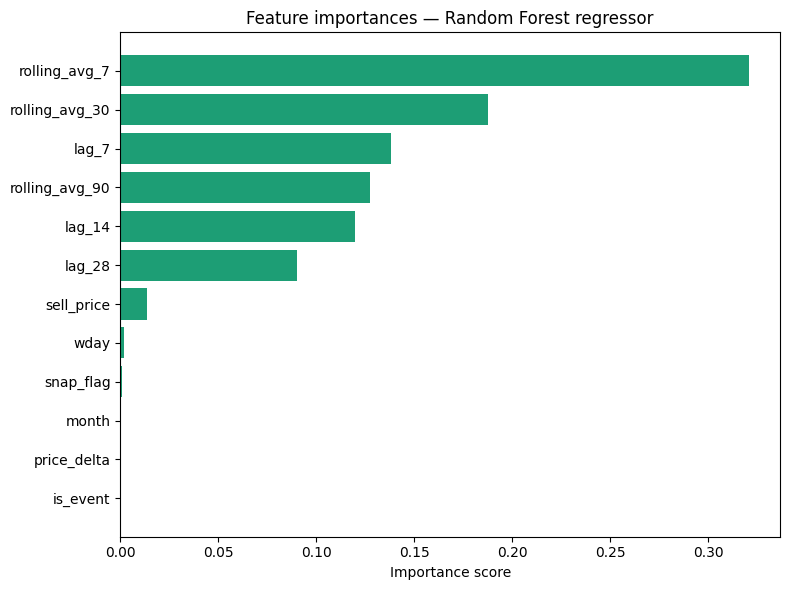

In [9]:
#Feature Importance
import matplotlib.pyplot as plt
import pandas as pd

#Get importances from the best regression model (RF)
importances = rf_model.featureImportances.toArray()

feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="#1D9E75")
plt.title("Feature importances — Random Forest regressor")
plt.xlabel("Importance score")
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150)
plt.show()

In [10]:
#Save the results to Google Drive
import os, shutil

save_dir = '/content/drive/MyDrive/MIS584_Project/Phase3_Results'
os.makedirs(save_dir, exist_ok=True)

# Save regression results
reg_df = pd.DataFrame(regression_results).T
reg_df.to_csv(f"{save_dir}/regression_results.csv")

# Save classification results
clf_df = pd.DataFrame(classification_results).T
clf_df.to_csv(f"{save_dir}/classification_results.csv")

# Save sensitivity results
sens_df = pd.DataFrame(sensitivity_results).T
sens_df.to_csv(f"{save_dir}/sensitivity_results.csv")

# Save plots
for f in os.listdir('.'):
    if f.endswith('.png'):
        shutil.copy(f, os.path.join(save_dir, f))

print("All results and plots saved to Drive")

All results and plots saved to Drive
